# Exploratory Data Analysis & Baseline Retrieval Quality

**Purpose:** Characterize the dataset and the FAISS-only retrieval landscape before any feedback is applied. All analyses use only local data (CSV, Parquet, FAISS index) — no API calls.

**When to use this notebook:** (a) to understand the raw data distribution, (b) to identify where feedback has room to help vs. where it can only hurt, (c) as a paper appendix documenting retrieval methodology.

**Data sources:** `tickets_large_first_reply_label.csv` (raw), `dataset.parquet` (canonicalized), `retrieval_quality_*.csv` (pre-computed FAISS stats).

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

ROOT = Path.cwd()
DATA = ROOT / "data" / "processed"
RAW_CSV = ROOT.parent / "notebooks" / "tickets_large_first_reply_label.csv"

print(f"Root: {ROOT}")
print(f"Data dir: {DATA}")
print(f"Raw CSV: {RAW_CSV}  exists={RAW_CSV.exists()}")

Root: c:\Users\ailab\Documents\code\financial-pilot-ea\paper_ieee_access\notebooks
Data dir: c:\Users\ailab\Documents\code\financial-pilot-ea\paper_ieee_access\notebooks\data\processed
Raw CSV: c:\Users\ailab\Documents\code\financial-pilot-ea\paper_ieee_access\notebooks\tickets_large_first_reply_label.csv  exists=False


## 2. Dataset Overview — Raw CSV Statistics

In [4]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw = df_raw[df_raw["Ref"].notna()].copy()  # drop 1 junk row
print(f"Raw rows (clean): {len(df_raw)}")
print(f"Unique Ref: {df_raw['Ref'].nunique()}")
print(f"Unique teams: {df_raw['Team->Name'].nunique()}")
print(f"Unique subcategories: {df_raw['Service subcategory->Name'].nunique()}")
print(f"Unique labels (label_auto): {df_raw['label_auto'].nunique()}")

Raw rows (clean): 1596
Unique Ref: 1589
Unique teams: 37
Unique subcategories: 149
Unique labels (label_auto): 118


In [5]:
# Reply characteristics
reply = df_raw["first_reply"]
desc = df_raw["Description_anon"].fillna("")

stats = pd.DataFrame({
    "Metric": ["Mean reply length", "Median reply length", "Std reply length",
               "Form-redirect replies", "Auto-created replies", "English-request replies",
               "Mean description length", "Median description length", "No description",
               "Description < 50 chars"],
    "Value": [
        f"{reply.str.len().mean():.0f} chars",
        f"{reply.str.len().median():.0f} chars",
        f"{reply.str.len().std():.0f} chars",
        f"{reply.str.contains('below you will find the additional form', case=False).sum()} ({100*reply.str.contains('below you will find the additional form', case=False).mean():.1f}%)",
        f"{reply.str.contains('This additional ticket is automatically created', case=False).sum()} ({100*reply.str.contains('This additional ticket is automatically created', case=False).mean():.1f}%)",
        f"{reply.str.contains('describe your request in English', case=False).sum()}",
        f"{desc.str.len().mean():.0f} chars",
        f"{desc.str.len().median():.0f} chars",
        f"{(desc == '').sum()}",
        f"{(desc.str.len() < 50).sum()}",
    ]
})
stats

,Metric,Value
0,Mean reply length,1352 chars
1,Median reply length,800 chars
2,Std reply length,1508 chars
3,Form-redirect replies,1187 (74.4%)
4,Auto-created replies,254 (15.9%)
5,English-request replies,7
6,Mean description length,293 chars
7,Median description length,179 chars
8,No description,1
9,Description < 50 chars,124


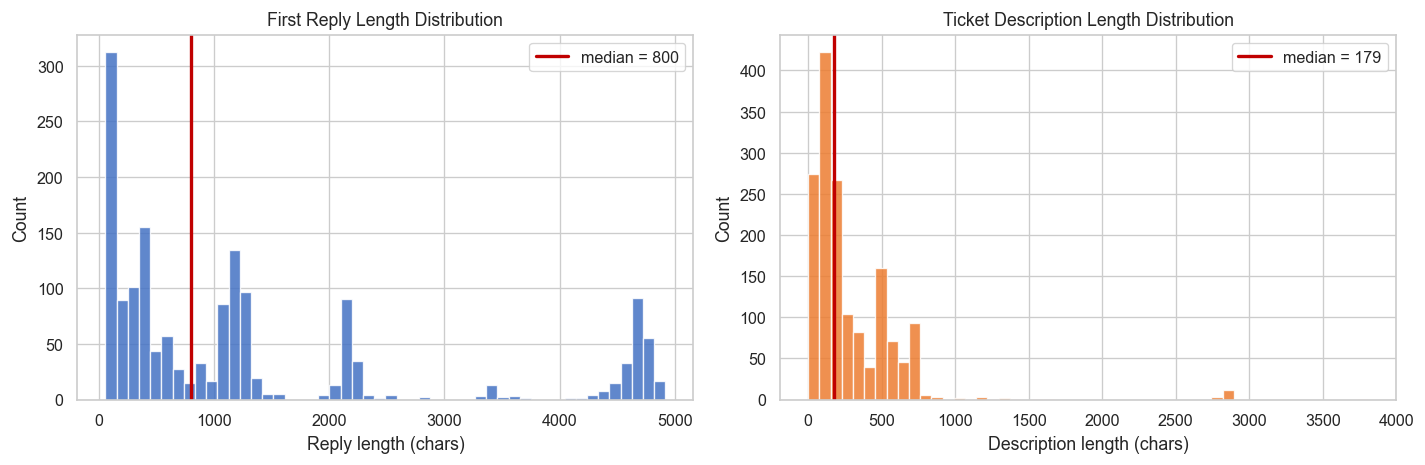

In [8]:
# Reply length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(reply.str.len(), bins=50, color="#4472C4", edgecolor="white", alpha=0.85)
axes[0].axvline(reply.str.len().median(), color="#C00000", linewidth=2, label=f"median = {reply.str.len().median():.0f}")
axes[0].set_xlabel("Reply length (chars)")
axes[0].set_ylabel("Count")
axes[0].set_title("First Reply Length Distribution")
axes[0].legend()

axes[1].hist(desc.str.len(), bins=50, color="#ED7D31", edgecolor="white", alpha=0.85)
axes[1].axvline(desc.str.len().median(), color="#C00000", linewidth=2, label=f"median = {desc.str.len().median():.0f}")
axes[1].set_xlabel("Description length (chars)")
axes[1].set_ylabel("Count")
axes[1].set_title("Ticket Description Length Distribution")
axes[1].legend()
plt.tight_layout()
#plt.savefig(DATA / "eda_reply_desc_length.png", dpi=150)
plt.show()

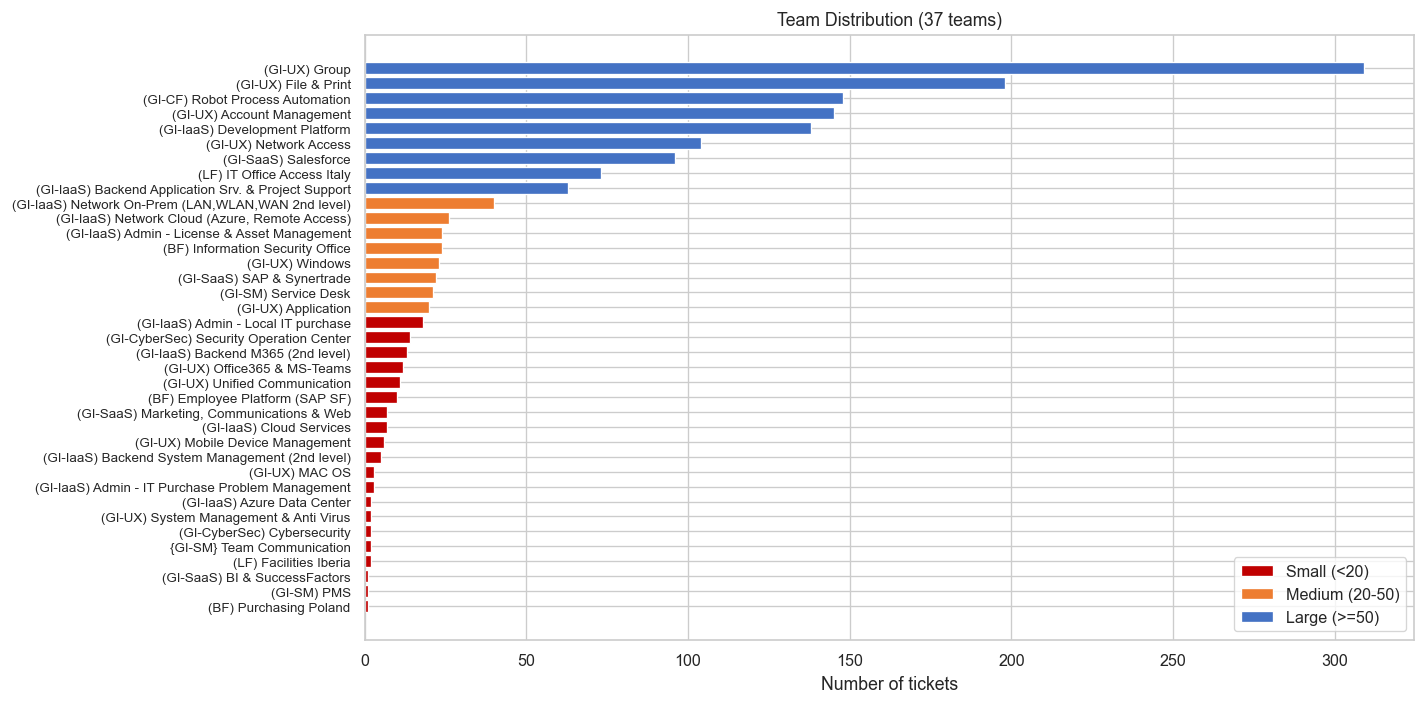

In [9]:
# Team distribution
team_counts = df_raw["Team->Name"].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#C00000" if c < 20 else "#4472C4" if c >= 50 else "#ED7D31" for c in team_counts.values]
ax.barh(range(len(team_counts)), team_counts.values, color=colors)
ax.set_yticks(range(len(team_counts)))
ax.set_yticklabels(team_counts.index, fontsize=8)
ax.set_xlabel("Number of tickets")
ax.set_title(f"Team Distribution ({len(team_counts)} teams)")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#C00000", label="Small (<20)"),
    Patch(facecolor="#ED7D31", label="Medium (20-50)"),
    Patch(facecolor="#4472C4", label="Large (>=50)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
#plt.savefig(DATA / "eda_team_distribution.png", dpi=150)
plt.show()

In [10]:
# Request type breakdown
df_raw["Request Type"].value_counts()

Request Type
Service request    1453
Incident            143
Name: count, dtype: int64

## 3. Baseline Retrieval Quality — Dev Set (319 queries, seed 42)

Pre-computed FAISS top-5 stats from `retrieval_quality_dev_seed42.csv`.
These were generated by `experiments/02_build_index.py` using `all-MiniLM-L6-v2` embeddings
with self-exclusion (the query's own ticket is removed from the candidate pool).

In [14]:
ret_dev = pd.read_csv("retrieval_quality_dev_seed42.csv")
print(f"Loaded {len(ret_dev)} dev queries")
ret_dev[["seq_id", "team", "intent_class", "top1_faiss", "top5_mean", "retrieval_margin", "is_form_reply"]].head(10)

Loaded 319 dev queries


,seq_id,team,intent_class,top1_faiss,top5_mean,retrieval_margin,is_form_reply
0,R-100,(GI-IaaS) Admin - Local IT purchase,other,0.441731,0.426281,0.000971,0
1,R-1002,(GI-UX) File & Print,onboarding,0.983543,0.982344,0.000787,0
2,R-1003,(GI-UX) Account Management,onboarding,0.989849,0.987711,0.002394,1
3,R-1004,(GI-UX) File & Print,onboarding,0.980211,0.976065,0.004369,0
4,R-1006,(GI-IaaS) Development Platform,software_license,0.927318,0.900359,0.000000,1
5,R-1007,(GI-UX) Group,vpn_access,0.790414,0.683261,0.101437,1
6,R-1016,(GI-UX) Group,software_support,0.770973,0.730561,0.032228,1
7,R-1020,(BF) Information Security Office,admin_rights,0.741129,0.694742,0.032096,1
8,R-1021,(GI-SM) Service Desk,other,0.546430,0.499587,0.021749,0
9,R-1024,(GI-UX) Windows,admin_rights,0.994577,0.874380,0.133149,1


In [15]:
top1 = ret_dev["top1_faiss"]

print("=== Overall stats ===")
print(f"Mean: {top1.mean():.3f}")
print(f"Median: {top1.median():.3f}")
print(f"Std: {top1.std():.3f}")
print(f"Min: {top1.min():.3f}")
print(f"Max: {top1.max():.3f}")

=== Overall stats ===
Mean: 0.808
Median: 0.845
Std: 0.169
Min: 0.345
Max: 1.000


In [16]:
# Difficulty buckets
buckets = [
    (0.00, 0.55, "Lost causes", "#C00000"),
    (0.55, 0.70, "Sweet spot (low)", "#ED7D31"),
    (0.70, 0.85, "Sweet spot (high)", "#70AD47"),
    (0.85, 0.95, "Risky", "#5B9BD5"),
    (0.95, 1.01, "Perfect", "#264478"),
]

bucket_rows = []
for lo, hi, label, color in buckets:
    n = ((top1 >= lo) & (top1 < hi)).sum()
    bucket_rows.append({
        "Bucket": f"{lo:.2f}-{hi:.2f}",
        "Label": label,
        "n": n,
        "%": 100 * n / len(top1),
        "Interpretation": "Even max lift (+0.20) unlikely to rescue" if lo < 0.55 else
                          "Feedback can meaningfully re-rank" if lo < 0.85 else
                          "Good baseline; feedback may displace correct candidates" if lo < 0.95 else
                          "Near-identical templates; feedback can only hurt"
    })

pd.DataFrame(bucket_rows)

,Bucket,Label,n,%,Interpretation
0,0.00-0.55,Lost causes,31,9.717868,Even max lift (+0.20) unlikely to rescue
1,0.55-0.70,Sweet spot (low),53,16.614420,Feedback can meaningfully re-rank
2,0.70-0.85,Sweet spot (high),79,24.764890,Feedback can meaningfully re-rank
3,0.85-0.95,Risky,60,18.808777,Good baseline; feedback may displace correct c...
4,0.95-1.01,Perfect,96,30.094044,Near-identical templates; feedback can only hurt


In [17]:
# Quintile analysis
quintiles = np.percentile(top1, [20, 40, 60, 80])
q_rows = []
bounds = [(0.0, quintiles[0])] + [(quintiles[i], quintiles[i+1]) for i in range(3)] + [(quintiles[3], 1.01)]
for i, (lo, hi) in enumerate(bounds):
    mask = (top1 >= lo) & (top1 < hi) if i < 4 else (top1 >= lo)
    subset = top1[mask]
    q_rows.append({
        "Quintile": i + 1,
        "Range": f"{lo:.3f}-{hi:.3f}",
        "n": len(subset),
        "Mean FAISS": subset.mean(),
        "Median FAISS": subset.median(),
    })
pd.DataFrame(q_rows)

,Quintile,Range,n,Mean FAISS,Median FAISS
0,1,0.000-0.632,64,0.538593,0.551664
1,2,0.632-0.792,64,0.720594,0.727401
2,3,0.792-0.898,63,0.846215,0.845246
3,4,0.898-0.979,64,0.946010,0.951847
4,5,0.979-1.010,64,0.988876,0.988090


C:\Users\ailab\AppData\Local\Temp\ipykernel_31624\789806866.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(q_data, labels=q_labels, patch_artist=True)


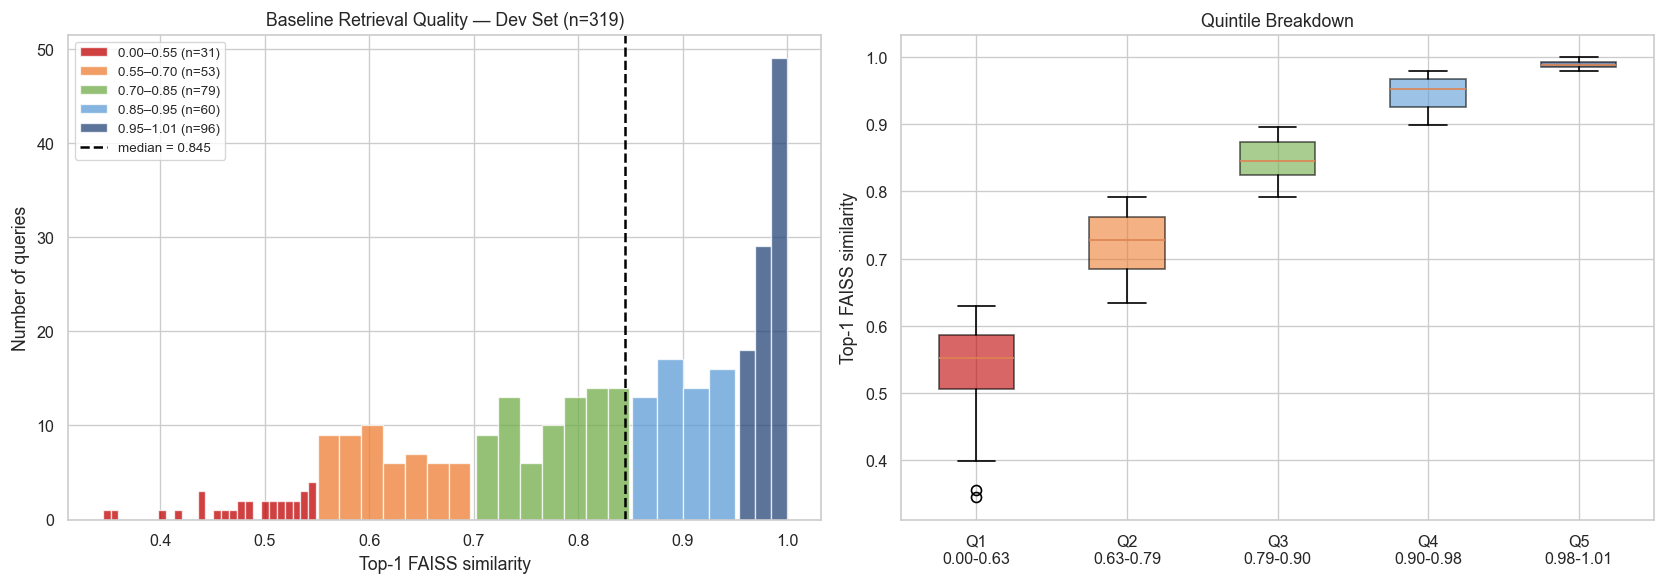

In [19]:
# Main retrieval quality figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
colors_bins = {
    (0.00, 0.55): "#C00000",
    (0.55, 0.70): "#ED7D31",
    (0.70, 0.85): "#70AD47",
    (0.85, 0.95): "#5B9BD5",
    (0.95, 1.01): "#264478",
}
for (lo, hi), col in colors_bins.items():
    mask = (top1 >= lo) & (top1 < hi)
    ax.hist(top1[mask], bins=int((hi-lo)*50), color=col, alpha=0.75,
           label=f"{lo:.2f}–{hi:.2f} (n={mask.sum()})")
ax.axvline(top1.median(), color="black", linestyle="--", linewidth=1.5, label=f"median = {top1.median():.3f}")
ax.set_xlabel("Top-1 FAISS similarity")
ax.set_ylabel("Number of queries")
ax.set_title(f"Baseline Retrieval Quality — Dev Set (n={len(top1)})")
ax.legend(fontsize=8)

# Quintile box plot
ax = axes[1]
q_data = []
q_labels = []
for i, (lo, hi) in enumerate(bounds):
    mask = (top1 >= lo) & (top1 < hi) if i < 4 else (top1 >= lo)
    q_data.append(top1[mask].values)
    q_labels.append(f"Q{i+1}\n{lo:.2f}-{hi:.2f}")
bp = ax.boxplot(q_data, labels=q_labels, patch_artist=True)
for patch, col in zip(bp["boxes"], ["#C00000", "#ED7D31", "#70AD47", "#5B9BD5", "#264478"]):
    patch.set_facecolor(col)
    patch.set_alpha(0.6)
ax.set_ylabel("Top-1 FAISS similarity")
ax.set_title("Quintile Breakdown")

plt.tight_layout()
#plt.savefig(DATA / "retrieval_quality_overview.png", dpi=150)
plt.show()

## 4. Per-Team and Per-Class Retrieval Quality

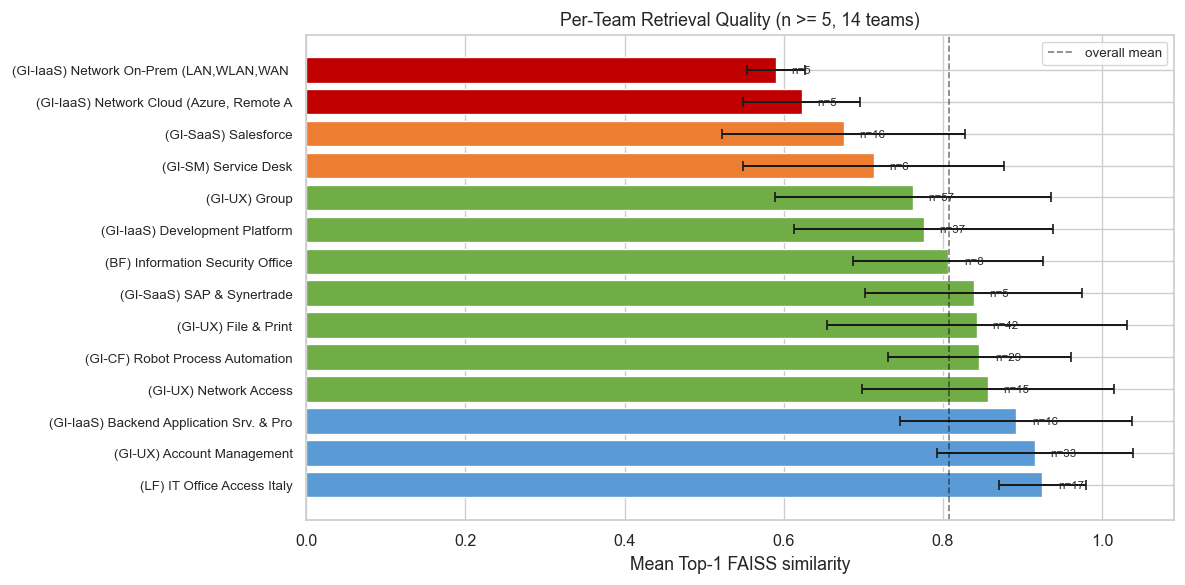

In [21]:
# Per-team retrieval quality (n >= 5)
team_stats = ret_dev.groupby("team").agg(
    n=("top1_faiss", "count"),
    mean_top1=("top1_faiss", "mean"),
    std_top1=("top1_faiss", "std"),
    mean_margin=("retrieval_margin", "mean"),
).query("n >= 5").sort_values("mean_top1")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(team_stats)), team_stats["mean_top1"],
               xerr=team_stats["std_top1"], capsize=3,
               color=["#C00000" if v < 0.65 else "#ED7D31" if v < 0.75 else "#70AD47" if v < 0.88 else "#5B9BD5" for v in team_stats["mean_top1"].values])
ax.set_yticks(range(len(team_stats)))
ax.set_yticklabels([t[:40] for t in team_stats.index], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Mean Top-1 FAISS similarity")
ax.set_title(f"Per-Team Retrieval Quality (n >= 5, {len(team_stats)} teams)")

for i, (_, row) in enumerate(team_stats.iterrows()):
    ax.text(row["mean_top1"] + 0.02, i, f"n={int(row['n'])}", va="center", fontsize=7)

ax.axvline(0.808, color="black", linestyle="--", linewidth=1, alpha=0.5, label="overall mean")
ax.legend(fontsize=8)
plt.tight_layout()
#plt.savefig(DATA / "retrieval_per_team.png", dpi=150)
plt.show()

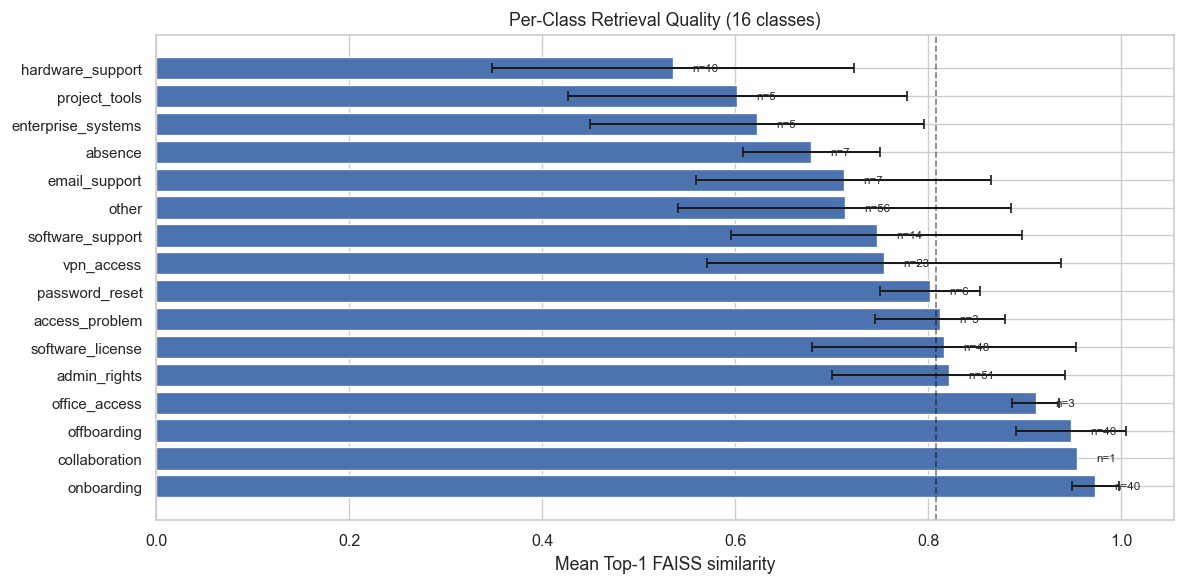

In [23]:
# Per-class retrieval quality
class_stats = ret_dev.groupby("intent_class").agg(
    n=("top1_faiss", "count"),
    mean_top1=("top1_faiss", "mean"),
    std_top1=("top1_faiss", "std"),
).sort_values("mean_top1")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(class_stats)), class_stats["mean_top1"],
               xerr=class_stats["std_top1"], capsize=3)
ax.set_yticks(range(len(class_stats)))
ax.set_yticklabels(class_stats.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Mean Top-1 FAISS similarity")
ax.set_title(f"Per-Class Retrieval Quality ({len(class_stats)} classes)")

for i, (_, row) in enumerate(class_stats.iterrows()):
    ax.text(row["mean_top1"] + 0.02, i, f"n={int(row['n'])}", va="center", fontsize=7)

ax.axvline(0.808, color="black", linestyle="--", linewidth=1, alpha=0.5)
plt.tight_layout()
#plt.savefig(DATA / "retrieval_per_class.png", dpi=150)
plt.show()

## 5. Retrieval Margin Analysis

Retrieval margin = top-1 FAISS - top-2 FAISS.  A small margin means the top-5 are all very similar (flat retrieval — common for template replies). A large margin means the top-1 is clearly better (peaked retrieval).

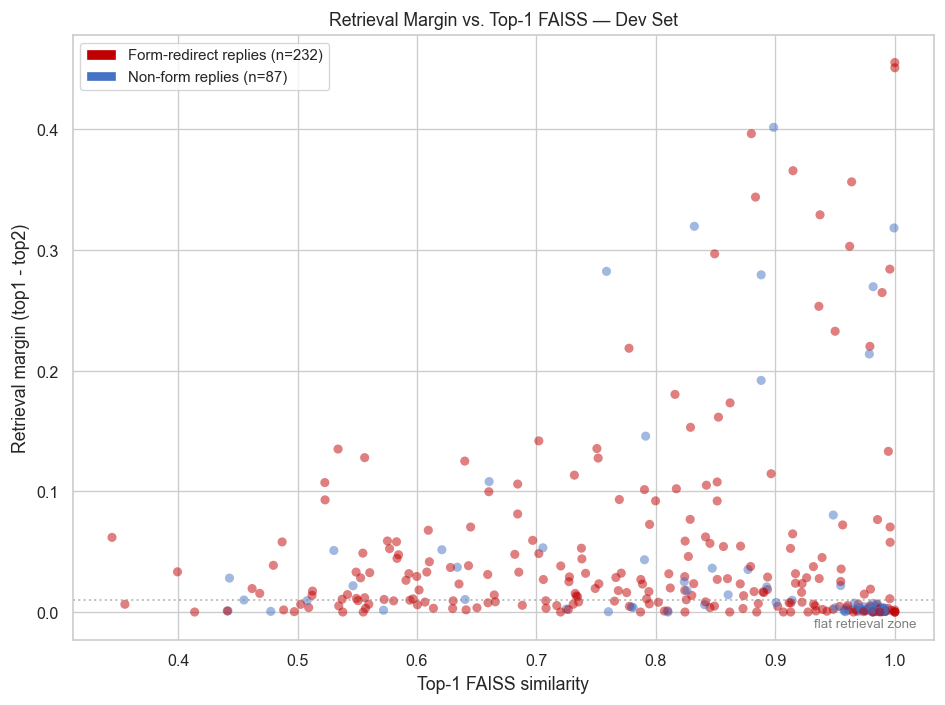

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    ret_dev["top1_faiss"], ret_dev["retrieval_margin"],
    c=ret_dev["is_form_reply"].map({1: "#C00000", 0: "#4472C4"}),
    alpha=0.5, s=30, edgecolors="none"
)
ax.set_xlabel("Top-1 FAISS similarity")
ax.set_ylabel("Retrieval margin (top1 - top2)")
ax.set_title("Retrieval Margin vs. Top-1 FAISS — Dev Set")

from matplotlib.patches import Patch
legend = [
    Patch(facecolor="#C00000", label=f"Form-redirect replies (n={ret_dev['is_form_reply'].sum()})"),
    Patch(facecolor="#4472C4", label=f"Non-form replies (n={(~ret_dev['is_form_reply'].astype(bool)).sum()})"),
]
ax.legend(handles=legend, fontsize=9)

ax.axhline(0.01, color="gray", linestyle=":", alpha=0.5)
ax.text(0.98, 0.02, "flat retrieval zone", transform=ax.transAxes, ha="right", fontsize=8, color="gray")
plt.tight_layout()
#plt.savefig(DATA / "retrieval_margin_scatter.png", dpi=150)
plt.show()

Margin stats: mean=0.0464  median=0.0134
Margins < 0.01: 149 queries
Margins > 0.05: 76 queries


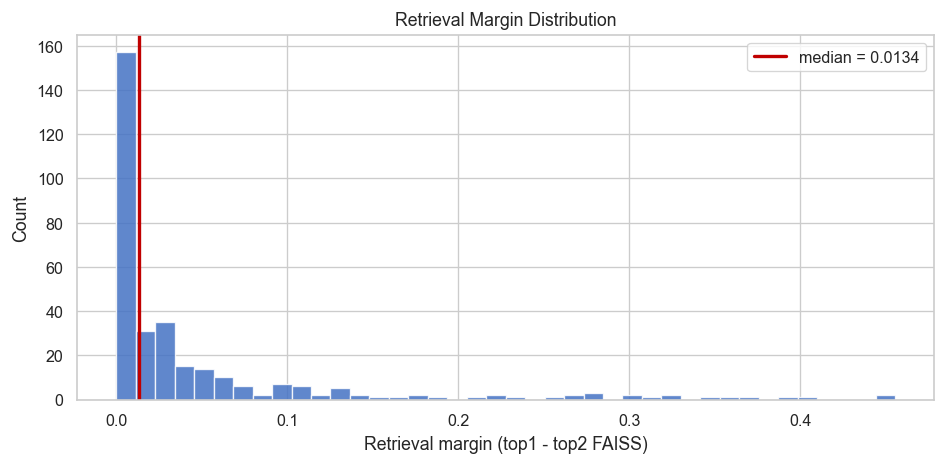

In [25]:
# Margin distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ret_dev["retrieval_margin"], bins=40, color="#4472C4", edgecolor="white", alpha=0.85)
ax.set_xlabel("Retrieval margin (top1 - top2 FAISS)")
ax.set_ylabel("Count")
ax.set_title("Retrieval Margin Distribution")
ax.axvline(ret_dev["retrieval_margin"].median(), color="#C00000", linewidth=2,
           label=f"median = {ret_dev['retrieval_margin'].median():.4f}")
ax.legend()

print(f"Margin stats: mean={ret_dev['retrieval_margin'].mean():.4f}  median={ret_dev['retrieval_margin'].median():.4f}")
print(f"Margins < 0.01: {(ret_dev['retrieval_margin'] < 0.01).sum()} queries")
print(f"Margins > 0.05: {(ret_dev['retrieval_margin'] > 0.05).sum()} queries")
plt.tight_layout()
#plt.savefig(DATA / "retrieval_margin_dist.png", dpi=150)
plt.show()

## 6. The Form-Redirect Problem

74% of reference replies are form-redirects ("Below you will find the additional form information..."). These create a structural ceiling on what feedback can achieve — if the baseline already retrieves the correct form template (top-1 > 0.90), promoting a different candidate can only make things worse.

Form-redirect queries: 232 / 319 (72.7%)
  Form queries top-1 FAISS: mean=0.781  median=0.810
  Non-form queries top-1 FAISS: mean=0.881  median=0.969


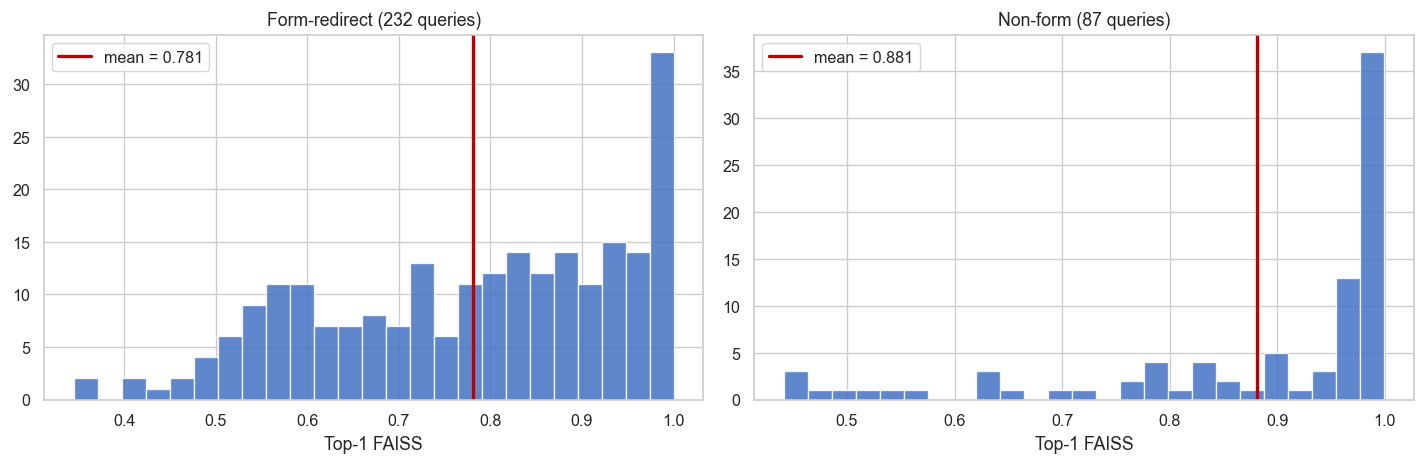

In [26]:
form_mask = ret_dev["is_form_reply"].astype(bool)

print(f"Form-redirect queries: {form_mask.sum()} / {len(ret_dev)} ({100*form_mask.sum()/len(ret_dev):.1f}%)")
print(f"  Form queries top-1 FAISS: mean={ret_dev.loc[form_mask, 'top1_faiss'].mean():.3f}  median={ret_dev.loc[form_mask, 'top1_faiss'].median():.3f}")
print(f"  Non-form queries top-1 FAISS: mean={ret_dev.loc[~form_mask, 'top1_faiss'].mean():.3f}  median={ret_dev.loc[~form_mask, 'top1_faiss'].median():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, mask) in zip(axes, [("Form-redirect", form_mask), ("Non-form", ~form_mask)]):
    ax.hist(ret_dev.loc[mask, "top1_faiss"], bins=25, color="#4472C4", edgecolor="white", alpha=0.85)
    ax.axvline(ret_dev.loc[mask, "top1_faiss"].mean(), color="#C00000", linewidth=2, label=f"mean = {ret_dev.loc[mask, 'top1_faiss'].mean():.3f}")
    ax.set_xlabel("Top-1 FAISS")
    ax.set_title(f"{label} ({mask.sum()} queries)")
    ax.legend()
plt.tight_layout()
#plt.savefig(DATA / "form_vs_nonform_retrieval.png", dpi=150)
plt.show()

## 7. Train Set Comparison

Verify that the train set retrieval quality distribution matches dev — if they differ substantially, the gate trained on train patterns may not transfer.

=== Train vs Dev comparison ===
Dev: top1 mean=0.808 median=0.845  margin mean=0.0464  form%=72.7%
Train: top1 mean=0.794 median=0.816  margin mean=0.0467  form%=74.7%


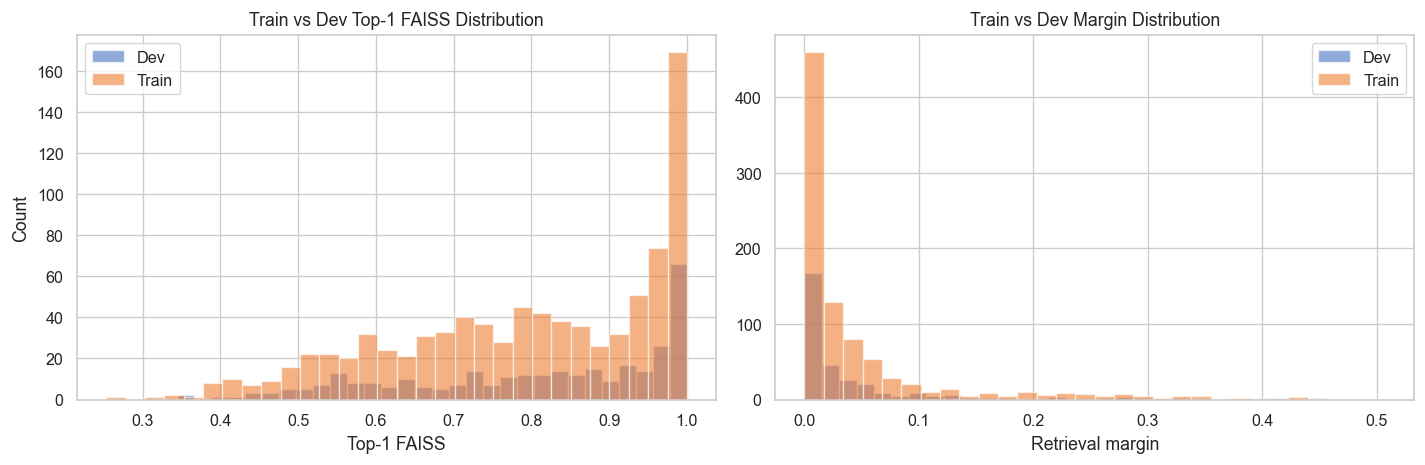

In [27]:
ret_train = pd.read_csv("retrieval_quality_train_seed42.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ret_dev["top1_faiss"], bins=30, color="#4472C4", alpha=0.6, label="Dev")
axes[0].hist(ret_train["top1_faiss"], bins=30, color="#ED7D31", alpha=0.6, label="Train")
axes[0].set_xlabel("Top-1 FAISS")
axes[0].set_ylabel("Count")
axes[0].set_title("Train vs Dev Top-1 FAISS Distribution")
axes[0].legend()

axes[1].hist(ret_dev["retrieval_margin"], bins=30, color="#4472C4", alpha=0.6, label="Dev")
axes[1].hist(ret_train["retrieval_margin"], bins=30, color="#ED7D31", alpha=0.6, label="Train")
axes[1].set_xlabel("Retrieval margin")
axes[1].set_title("Train vs Dev Margin Distribution")
axes[1].legend()

print("=== Train vs Dev comparison ===")
for label, df in [("Dev", ret_dev), ("Train", ret_train)]:
    print(f"{label}: top1 mean={df['top1_faiss'].mean():.3f} median={df['top1_faiss'].median():.3f}  "
          f"margin mean={df['retrieval_margin'].mean():.4f}  form%={100*df['is_form_reply'].mean():.1f}%")
plt.tight_layout()
#plt.savefig(DATA / "train_vs_dev_distribution.png", dpi=150)
plt.show()

## 8. Judging Depth Analysis

How deep must we judge FAISS candidates per query so that the lift formula can theoretically promote any candidate into the top-5?

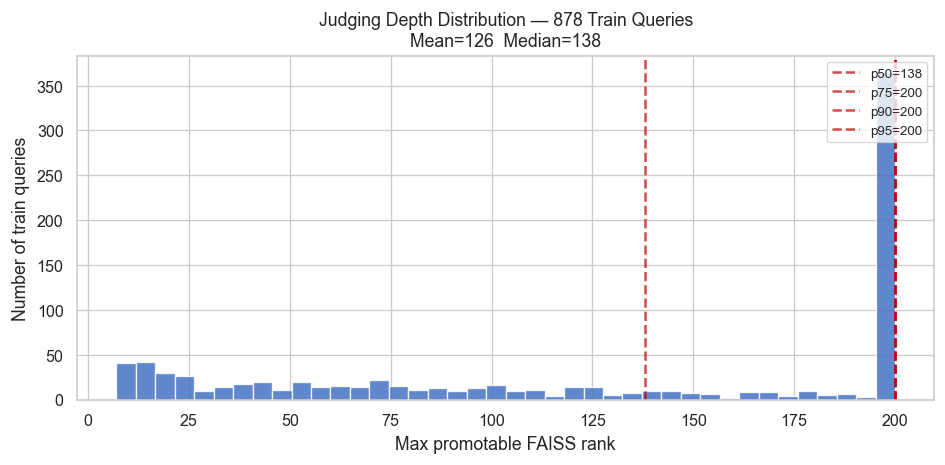

Percentiles:
  p50: 138
  p75: 200
  p90: 200
  p95: 200
  p99: 200

Note: N/A


In [37]:
import json
depth = json.loads(Path("recommended_judging_depth.json").read_text())

ranks = np.array(depth["ranks"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ranks, bins=40, color="#4472C4", edgecolor="white", alpha=0.85)
for p in [50, 75, 90, 95]:
    ax.axvline(np.percentile(ranks, p), color="#C00000", linestyle="--", 
               linewidth=1.5, alpha=0.7, label=f"p{p}={np.percentile(ranks, p):.0f}")
ax.set_xlabel("Max promotable FAISS rank")
ax.set_ylabel("Number of train queries")
ax.set_title(f"Judging Depth Distribution — {len(ranks)} Train Queries\n"
             f"Mean={ranks.mean():.0f}  Median={np.median(ranks):.0f}")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
#plt.savefig(DATA / "judging_depth_distribution.png", dpi=150)
plt.show()

print("Percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(ranks, p):.0f}")
print(f"\nNote: {depth.get('note', 'N/A')}")

## 9. Data-Level Claims Summary

| # | Claim | Evidence |
|---|-------|----------|
| C1 | Retrieval quality is bimodal — 30% near-perfect (>0.95), 10% very poor (<0.55), 60% in a usable middle | Sec 3 difficulty buckets |
| C2 | 74% of reference replies are form-redirects, creating a natural ceiling on what feedback can improve | Sec 2, 6 |
| C3 | Per-team retrieval quality varies by 2× (0.59 → 0.93 top-1 FAISS) | Sec 4 |
| C4 | Per-class retrieval quality similarly ranges from 0.54 (hardware) to 0.97 (onboarding) | Sec 4 |
| C5 | The retrieval margin distribution is bimodal — flat for templates, peaked for unique queries | Sec 5 |
| C6 | Train and dev retrieval quality distributions are well-matched (top-1 FAISS means within 0.014) | Sec 7 |
| C7 | FAISS scores are flat enough that even at rank 500, candidates remain theoretically promotable | Sec 8 |
| C8 | The feedback "sweet spot" (top-1 FAISS 0.55–0.85) covers ~42% of queries | Sec 3 |

## 10. Reproducibility

All figures saved to `data/processed/`. All statistics derived from:
- `retrieval_quality_dev_seed42.csv` / `retrieval_quality_train_seed42.csv` — generated by running FAISS top-5 search over the dev/train splits with `all-MiniLM-L6-v2`, self-excluded.
- `tickets_large_first_reply_label.csv` — the raw CSV source.
- `recommended_judging_depth.json` — produced by `experiments/02_build_index.py`.

No API keys or LLM calls used.